In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd


from CleanData import CleanData
from GettingTrainingData.db import startup

conn = startup()
df_trades  = pd.read_sql("SELECT * FROM trades",conn)
df_markets = pd.read_sql("SELECT * FROM markets", conn).rename(columns={'outcome': 'market_outcome','createdAt':'marketCreate'})
df_users   = pd.read_sql("SELECT * FROM users", conn)

df = CleanData(df_trades,df_markets,df_users) 
print(df.shape)

(730356, 42)


In [4]:
cur = conn.cursor()
trade = cur.execute("SELECT * FROM trades")
trade = trade.fetchone()
print(trade)

('0xffdbbf2c3b9aa808abbcb35beb2b20a93572570aa5dd1bd1b630cade2f809f26', '0x67af214764bd6eda61fadb25cdcbea6d13d761ee', '1776034013', 0.10033333333333333, 30.0, 'Yes', 0, 0, '0x9fb84a1c894a26bcd8e2edaedddbdfcbaba3a8dec563d88bce4ae388b782010a', 0)


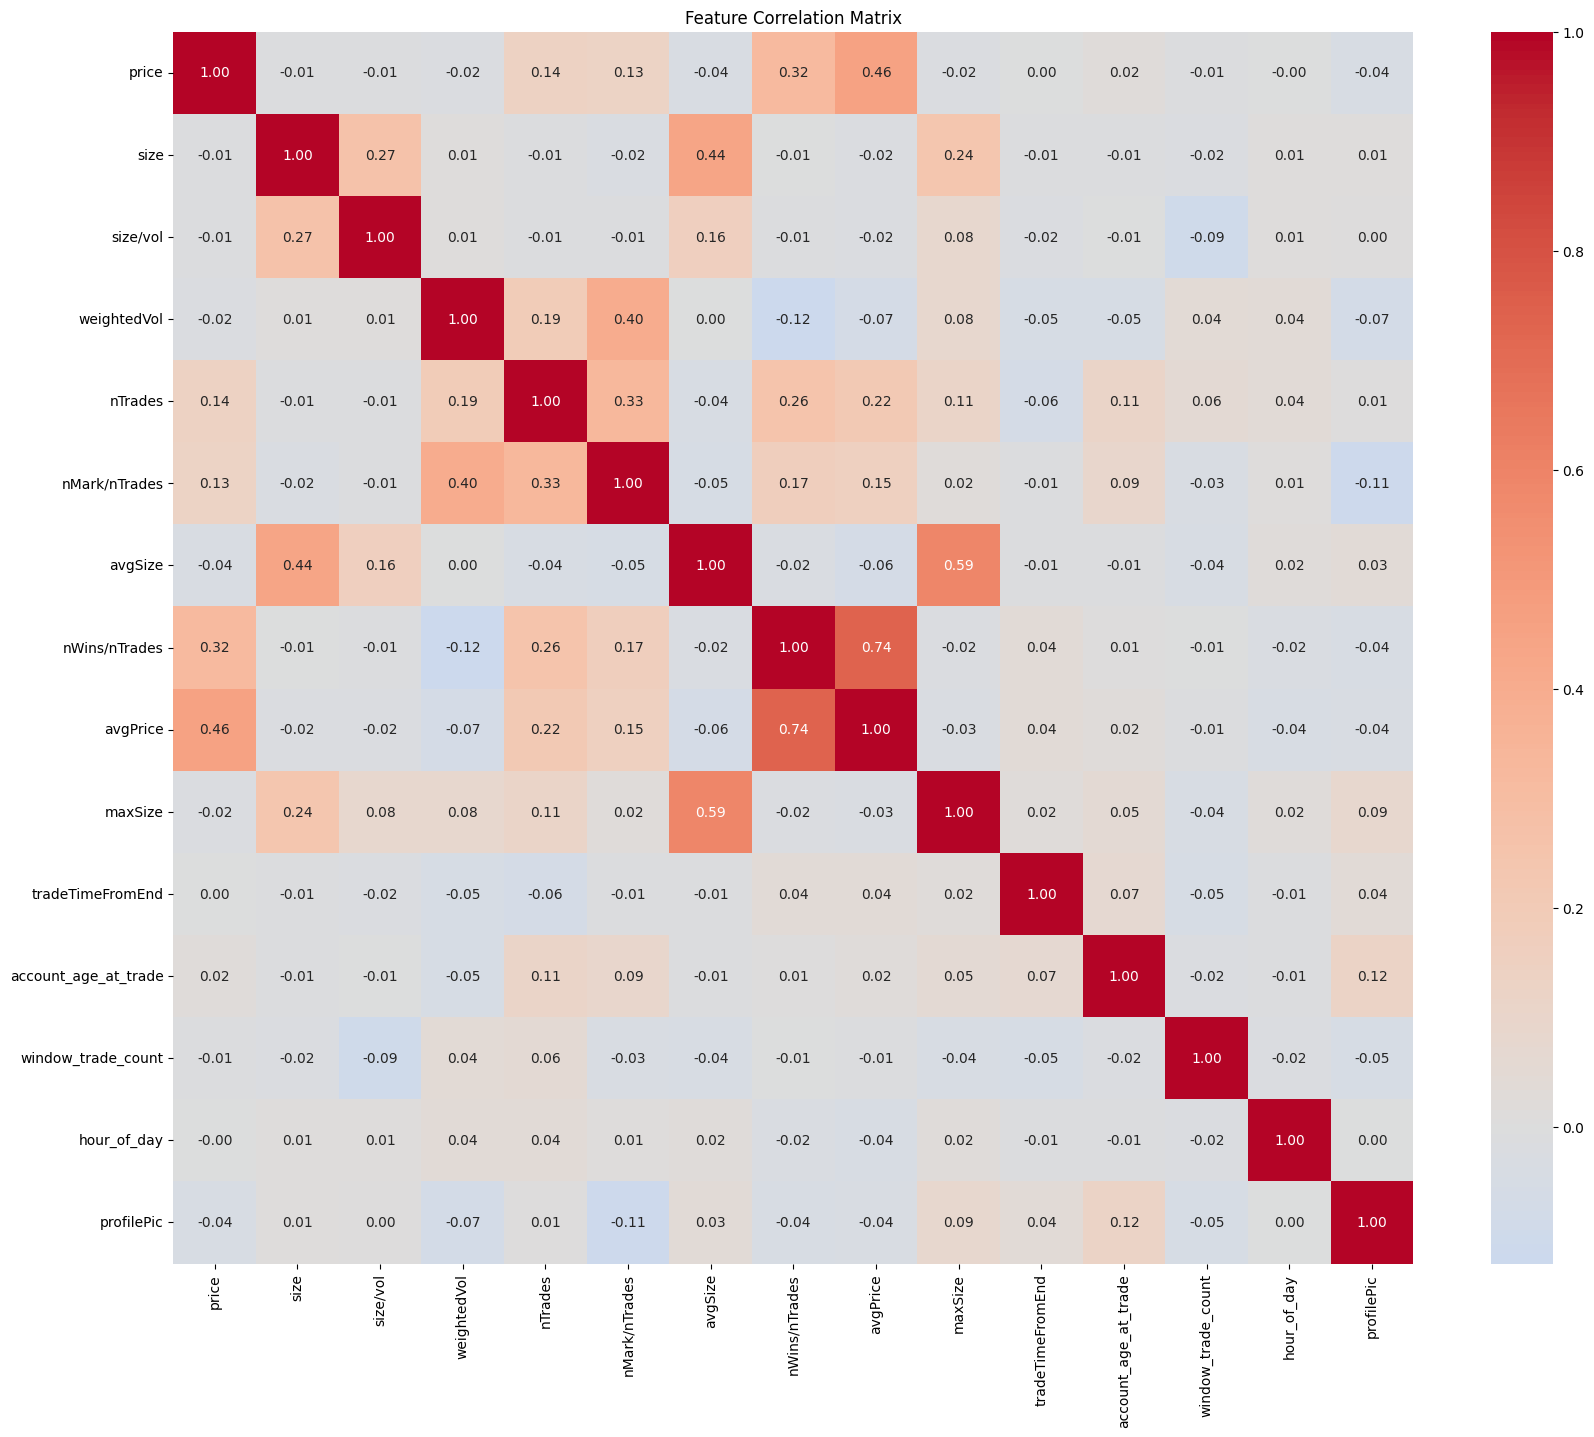

In [21]:
from matplotlib import pyplot as plt
import seaborn as sns

features = ['price', 'size', 'size/vol','weightedVol','nTrades','nMark/nTrades','avgSize','nWins/nTrades','avgPrice','maxSize','tradeTimeFromEnd','account_age_at_trade','window_trade_count','hour_of_day','profilePic']
    
corr_matrix = df[features].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            annot=True,      # show values
            fmt='.2f',       # 2 decimal places
            cmap='coolwarm', # red=positive, blue=negative
            center=0)        # center colormap at 0

plt.title('Feature Correlation Matrix')
plt.show()

In [4]:
from RealWorldTest.RealWorldTesting import testOnNewMarkets

df_test1 = testOnNewMarkets(features,210)
print('df1 Done')
df_test2 = testOnNewMarkets(features,220)
df_test3 = testOnNewMarkets(features,230)
df_test4 = testOnNewMarkets(features,240)
df_test5 = testOnNewMarkets(features,250)
df_test6 = testOnNewMarkets(features,260)

dfs = {
    1:df_test1,
    2:df_test2,
    3:df_test3,
    4:df_test4,
    5:df_test5,

}
print('Done!')

1963

  ────────────────────────────────────────────────────────
  Will Liverpool FC win on 2026-01-01?
  Condition_id: 0x82d883868400fb98efebdf57f63fd425a950682b1d51364c72a86fa268521e58
  ────────────────────────────────────────────────────────
  Yes          [....................]   0.0%
  No           [####################] 100.0%
  Volume  : $5,120,126.37  
  Liq     : $        0.00
  Flags   : active | closed | restricted | approved
  ────────────────────────────────────────────────────────

df1 Done
1046

  ────────────────────────────────────────────────────────
  Islanders vs. Oilers
  Condition_id: 0xcaf068cacdf99e25965a6bd8eafdddd2652a708ba92b54a16f7d7a914fe5eb34
  ────────────────────────────────────────────────────────
  Islanders    [####################] 100.0%
  Oilers       [....................]   0.0%
  Volume  : $1,279,089.00  
  Liq     : $        0.00
  Flags   : active | closed | restricted | approved
  ────────────────────────────────────────────────────────

195

In [12]:
for i in range(1,5):
    print(len(dfs[i]))

832
507
1770
722


In [26]:
from modelsMachine import XGBoostME

epsilon = 0.05
models = []
for i in [20,30,40,2000]:
    model = XGBoostME(df,features,i)
    models.append(model)

(46354, 41)
Train accuracy: 0.800
Test accuracy:  0.720
(64583, 41)
Train accuracy: 0.785
Test accuracy:  0.721
(81270, 41)
Train accuracy: 0.779
Test accuracy:  0.727
(730356, 41)
Train accuracy: 0.783
Test accuracy:  0.777


In [28]:
from RealWorldTest.RealWorldTesting import testOnNewMarkets
from modelsMachine import XGBoostME

epsilon = 0.05

for j in range(1,5):
    df_test = dfs.get(j)
    X = df_test[features]
    y = df_test['won']

    test_df = df_test.loc[X.index].copy() # copy from df the test data by index
    test_df['predicted_won'] = model.predict(X) # put result into a column
    test_df['confidence'] = model.predict_proba(X)[:, 1]
    # make new df where we only take trades we took (ie.) if we predicted it was right/allign we the market outcome and only with good confidence
    for model in models:
        bought_trades = test_df[(test_df['predicted_won'] == 1)&(test_df['confidence']>0.7)].copy()
        bought_count = bought_trades.groupby('outcome').agg(count = ('outcome','count'))
        print(bought_count)
        print(bought_trades.iloc[1,bought_trades.columns.get_loc('market_outcome')])

        # if the trade we bought won (row['won']==1) than we gain 1-price -platformcut, according to polymarket doc fee is = marketrate*p*q and market rate is about 0.05 for all markets
        bought_trades['return'] = bought_trades.apply(
            lambda row: (1 - row['price'] - (epsilon * (1-row['price']) * row['price'])) if row['won'] == 1 # the cost of a trade is already taken into account with -'price'
                    else (-row['price'] - (epsilon * (1-row['price']) * row['price'])), axis=1
        )

        # summary
        min_confidence = bought_trades['confidence'].min()
        max_confidence = bought_trades['confidence'].max()
        thoughtWouldWinOverTot = test_df['predicted_won'].sum()/len(test_df)
        total_trades    = len(bought_trades)
        total_invested  = bought_trades['price'].sum()
        total_return    = bought_trades['return'].sum()
        win_rate        = bought_trades['won'].mean()
        rate            = total_return / total_invested * 100
        print("-"*20)
        print(f"At MarketFeeRate:{epsilon*100}%")
        print(f"Trades taken:    {total_trades}")
        print(f"Win rate:        {win_rate:.3f}")
        print(f"Total invested:  ${total_invested:,.2f}")
        print(f"Total return:    ${total_return:,.2f}")
        print(f"ROI:             {rate:.2f}%")
        print(f"Min confidence:  {min_confidence}")
        print(f"Max confidence:  {max_confidence}")
        print(f"Ratio            {thoughtWouldWinOverTot}")

        bought_trades['price_bucket'] = pd.cut(bought_trades['price'], bins=[0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]) #cuts the df into bins by 'price'

        bucket_summary = bought_trades.groupby('price_bucket').agg(
            count        = ('return', 'count'),
            win_rate     = ('won', 'mean'),
            total_return = ('return', 'sum'),
            avg_return   = ('return', 'mean')
        )
        print(bucket_summary)


         count
outcome       
Yes        203
No
--------------------
At MarketFeeRate:5.0%
Trades taken:    203
Win rate:        0.000
Total invested:  $130.67
Total return:    $-132.99
ROI:             -101.78%
Min confidence:  0.7000517249107361
Max confidence:  0.7855983376502991
Ratio            0.6947115384615384
              count  win_rate  total_return  avg_return
price_bucket                                           
(0.6, 0.7]      203       0.0   -132.994063   -0.655143
         count
outcome       
Yes        203
No
--------------------
At MarketFeeRate:5.0%
Trades taken:    203
Win rate:        0.000
Total invested:  $130.67
Total return:    $-132.99
ROI:             -101.78%
Min confidence:  0.7000517249107361
Max confidence:  0.7855983376502991
Ratio            0.6947115384615384
              count  win_rate  total_return  avg_return
price_bucket                                           
(0.6, 0.7]      203       0.0   -132.994063   -0.655143
         count
outcome  